# Downloading Dataset

In [ ]:
!gdown 1bbiPjv9eb7kTRMz0rvo4Vt2rkxV847e7

Downloading...
From (original): https://drive.google.com/uc?id=1bbiPjv9eb7kTRMz0rvo4Vt2rkxV847e7
From (redirected): https://drive.google.com/uc?id=1bbiPjv9eb7kTRMz0rvo4Vt2rkxV847e7&confirm=t&uuid=54b7ee29-a1c6-4786-9be8-911325c550d9
To: /content/finetune_sharegpt.jsonl
100% 194M/194M [00:02<00:00, 77.2MB/s]


# Examples

In [ ]:
import os
import time
import json
from tqdm import tqdm


with open('finetune_sharegpt.jsonl') as f:
  data = [json.loads(sample) for sample in f.readlines()]

In [ ]:
data[0]

{'id': 'rice_blast_001',
 'crop': 'rice',
 'symptom_text': 'আমার ধানের পাতায় ছোট ছোট বাদামী রঙের দাগ দেখা যাচ্ছে। প্রথমে মনে হয়েছিল পোকা লেগেছে, কিন্তু দাগগুলো বাড়ছে।',
 'image_path': None,
 'disease_label': 'Rice Blast (ধানের ব্লাস্ট)',
 'qa_flow': [{'role': 'assistant',
   'content': 'আপনার ধানের পাতায় কী ধরনের দাগ দেখা যাচ্ছে? দাগগুলো কি চোখের মতো গোল, নাকি অন্য কোনো আকারের? এবং কি দাগগুলো পুরো পাতায় ছড়িয়ে পড়ছে?'},
  {'role': 'user',
   'content': 'দাগগুলো প্রথমে ছোট ছিল, এখন অনেকটা চোখের মতো দেখাচ্ছে। চারপাশে হালকা বাদামী আর ভেতরে ধূসর। পাতাগুলো ধীরে ধীরে শুকিয়ে যাচ্ছে।'},
  {'role': 'assistant',
   'content': 'আপনি কি গাছের কাণ্ড বা শীষেও কোনো দাগ বা পরিবর্তন লক্ষ্য করেছেন? যেমন, কাণ্ডের গিঁটে বা শীষের গোড়ায় কোনো দাগ?'},
  {'role': 'user',
   'content': 'হ্যাঁ, শীষের গোড়ায় একটু কালচে দেখাচ্ছে। মনে হচ্ছে শীষ বেরোনোর সময় ভেঙে যেতে পারে।'}],
 'advice': 'আপনার ধানের জমিতে ব্লাস্ট রোগ দেখা দিয়েছে। দ্রুত Tricyclazole বা Propiconazole স্প্রে করুন। ইউরিয়ার ব্যবহার কমিয়ে দিন এবং জমিতে সব

In [ ]:
def create_single_conversation(sample):

    single_sample = [{'role': 'user',
      'content': sample['symptom_text']
    }]

    for qa_entry in sample['qa_flow']:
      single_sample.append(qa_entry)

    single_sample.append({'role': 'assistant',
      'content': sample['advice'] + '\nNote: ' +  sample['notes']
    })

    return single_sample

In [ ]:
def fix_single_conversation(sample):
  merged = []
  last_role = None
  for s in sample:
    current_role = s['role']
    current_content = s['content']
    if last_role and last_role == current_role:
        merged[-1]['content'] += f'\n{current_content}'
    else:
        merged.append({'role': current_role, 'content': current_content})
        last_role = current_role
  return merged

# Data Structure

In [ ]:
dataset = []

for sample in tqdm(data):
  dataset.append(fix_single_conversation(create_single_conversation(sample)))

100%|██████████| 96311/96311 [00:00<00:00, 142714.58it/s]


In [ ]:
dataset[5]

[{'role': 'user',
  'content': 'ধানের পাতাগুলো দ্রুত হলুদ হয়ে যাচ্ছে এবং শুকিয়ে যাচ্ছে। মনে হচ্ছে যেন গাছ দুর্বল হয়ে পড়েছে।'},
 {'role': 'assistant',
  'content': 'পাতা হলুদ হওয়ার সাথে সাথে কি আপনি পাতায় কোনো ধরনের দাগ দেখতে পাচ্ছেন? যদি দেখেন, তাহলে দাগগুলো কেমন?'},
 {'role': 'user',
  'content': 'হ্যাঁ, পাতায় হালকা বাদামী রঙের ছোট ছোট দাগ দেখা যাচ্ছে। দাগগুলো প্রথমে ছোট ছিল, কিন্তু এখন বাড়ছে।'},
 {'role': 'assistant',
  'content': 'আপনি কি কাণ্ড বা কলার অংশে কোনো পরিবর্তন লক্ষ্য করেছেন? যেমন - কাণ্ড নরম হয়ে যাওয়া বা তাতে দাগ পড়া।'},
 {'role': 'user',
  'content': 'কাণ্ডটা একটু নরম মনে হচ্ছে, এবং সেখানেও হালকা বাদামী দাগ দেখা যাচ্ছে।'},
 {'role': 'assistant',
  'content': 'আপনার ধানের জমিতে শীথ ব্লাইট (Sheath Blight) রোগের লক্ষণ দেখা যাচ্ছে। এটি একটি গুরুতর রোগ, যা দ্রুত পুরো জমিতে ছড়িয়ে পড়তে পারে।\nএই রোগের জন্য Propiconazole গ্রুপের ছত্রাকনাশক ব্যবহার করুন। এছাড়া, রোগাক্রান্ত গাছগুলো দ্রুত সরিয়ে ফেলুন এবং জমিতে ভালোভাবে পানি নিষ্কাশনের ব্যবস্থা করুন।\nNote: শীথ ব্লাইট রোগের বিস্তার 

# Split

In [ ]:
train_dataset = dataset[:int(len(dataset) * 0.8)]
test_dataset = dataset[int(len(dataset) * 0.8):]

# Gemma3

In [ ]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    import torch; v = re.match(r"[0-9]{1,}\.[0-9]{1,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.33.post1" if v=="2.9" else "0.0.32.post2" if v=="2.8" else "0.0.29.post3")
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth
!pip install transformers==4.57.3
!pip install --no-deps trl==0.22.2
!pip install torchcodec
import torch; torch._dynamo.config.recompile_limit = 64;

In [ ]:
%%capture
!pip install --no-deps --upgrade timm

In [ ]:
from unsloth import FastModel
import torch
model, tokenizer = FastModel.from_pretrained(
    model_name = "unsloth/gemma-3-1b-it-unsloth-bnb-4bit",
    dtype = None,
    max_seq_length = 1024,
    load_in_4bit = True,
    full_finetuning = False,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.1.4: Fast Gemma3 patching. Transformers: 4.57.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gemma3 won't work! Using float32.
Unsloth: Gemma3 does not support SDPA - switching to fast eager.


model.safetensors:   0%|          | 0.00/1.00G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/233 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/670 [00:00<?, ?B/s]

In [ ]:
model = FastModel.get_peft_model(
    model,
    finetune_vision_layers     = False,
    finetune_language_layers   = True,
    finetune_attention_modules = True,
    finetune_mlp_modules       = True,
    r = 8,
    lora_alpha = 8,
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
)

Unsloth: Making `model.base_model.model.model` require gradients


In [ ]:
from unsloth import get_chat_template

processor = get_chat_template(
    tokenizer,
    "gemma-3"
)

# Fine Tuning

In [ ]:
from trl import SFTTrainer, SFTConfig
from datasets import Dataset

formatted_dataset = []
for conversation in dataset:
    formatted_text = processor.apply_chat_template(conversation, tokenize=False, add_generation_prompt=False)
    formatted_dataset.append({"text": formatted_text})

train_dataset_hf = Dataset.from_list(formatted_dataset)

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_dataset_hf,
    eval_dataset = None,
    args = SFTConfig(
        dataset_text_field = "text",
        per_device_train_batch_size = 1,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 30,
        learning_rate = 2e-4,
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "linear",
        seed = 3407,
        report_to = "none",
    ),
)

Unsloth: Switching to float32 training since model cannot work with float16


Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/96311 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


In [ ]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 96,311 | Num Epochs = 1 | Total steps = 30
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 6,522,880 of 1,006,408,832 (0.65% trained)


Step,Training Loss
1,2.339600
2,2.600700
3,2.391500
4,2.348100
5,2.126400
6,2.099600
7,2.001900
8,2.272000
9,1.960900
10,2.131000


In [ ]:
dataset[0]

[{'role': 'user',
  'content': 'আমার ধানের পাতায় ছোট ছোট বাদামী রঙের দাগ দেখা যাচ্ছে। প্রথমে মনে হয়েছিল পোকা লেগেছে, কিন্তু দাগগুলো বাড়ছে।'},
 {'role': 'assistant',
  'content': 'আপনার ধানের পাতায় কী ধরনের দাগ দেখা যাচ্ছে? দাগগুলো কি চোখের মতো গোল, নাকি অন্য কোনো আকারের? এবং কি দাগগুলো পুরো পাতায় ছড়িয়ে পড়ছে?'},
 {'role': 'user',
  'content': 'দাগগুলো প্রথমে ছোট ছিল, এখন অনেকটা চোখের মতো দেখাচ্ছে। চারপাশে হালকা বাদামী আর ভেতরে ধূসর। পাতাগুলো ধীরে ধীরে শুকিয়ে যাচ্ছে।'},
 {'role': 'assistant',
  'content': 'আপনি কি গাছের কাণ্ড বা শীষেও কোনো দাগ বা পরিবর্তন লক্ষ্য করেছেন? যেমন, কাণ্ডের গিঁটে বা শীষের গোড়ায় কোনো দাগ?'},
 {'role': 'user',
  'content': 'হ্যাঁ, শীষের গোড়ায় একটু কালচে দেখাচ্ছে। মনে হচ্ছে শীষ বেরোনোর সময় ভেঙে যেতে পারে।'},
 {'role': 'assistant',
  'content': 'আপনার ধানের জমিতে ব্লাস্ট রোগ দেখা দিয়েছে। দ্রুত Tricyclazole বা Propiconazole স্প্রে করুন। ইউরিয়ার ব্যবহার কমিয়ে দিন এবং জমিতে সবসময় পর্যাপ্ত পানি রাখুন।\nNote: ব্লাস্ট রোগ ধানের জন্য খুবই ক্ষতিকর। এটি দ্রুত ছড়াতে পারে এ

# Loss Curve

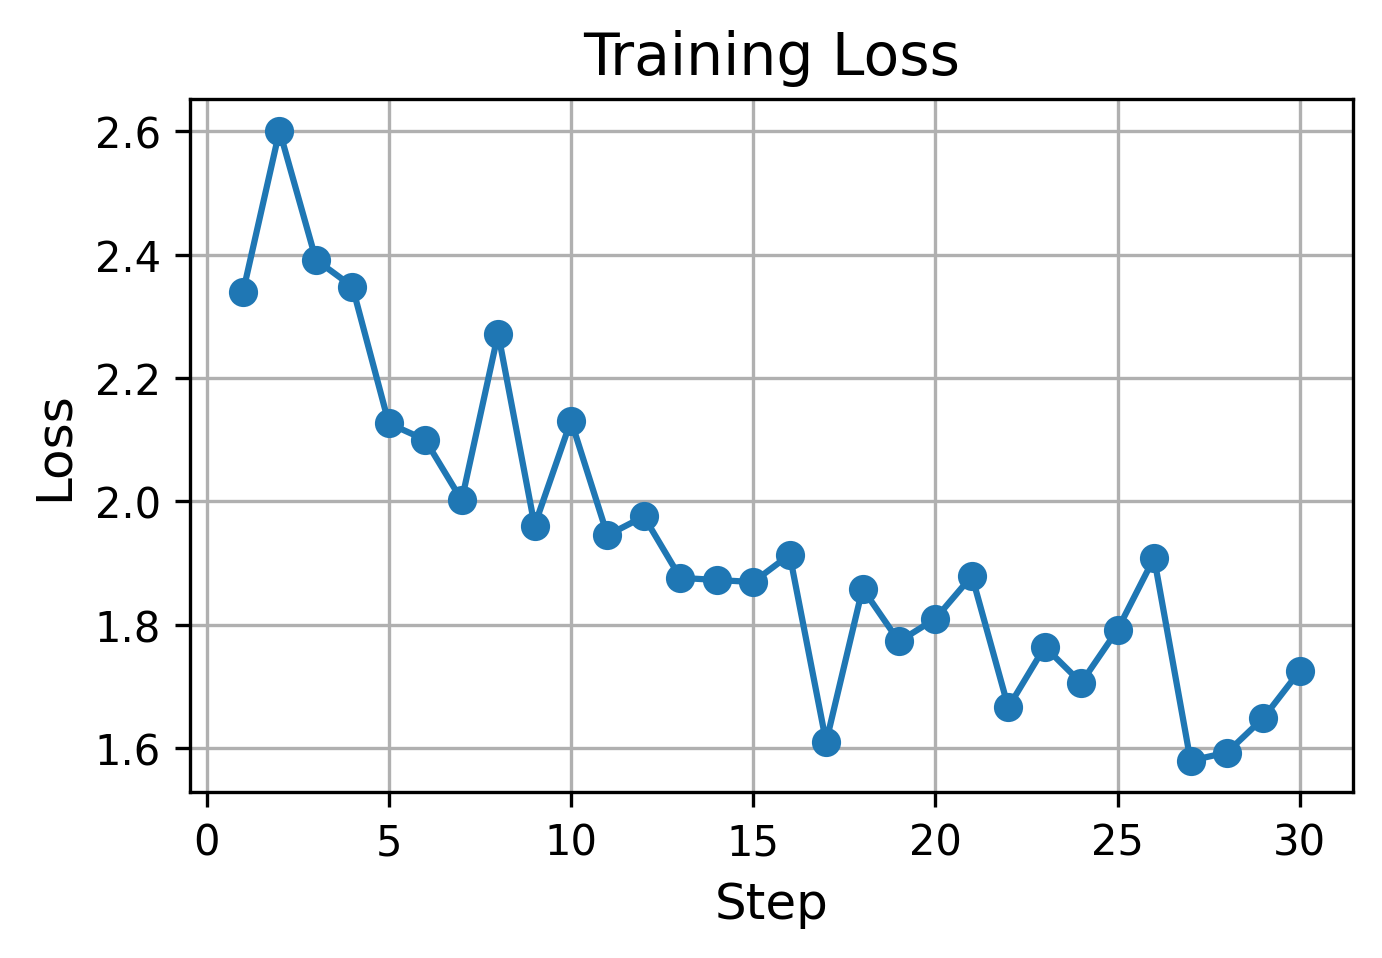

In [ ]:
import json
import matplotlib.pyplot as plt


log_history = trainer.state.log_history
if not log_history:
    print("No log history found in trainer_state.")
else:
    filtered_entries = [entry for entry in log_history if "step" in entry and "loss" in entry]

    steps = [entry["step"] for entry in filtered_entries]
    losses = [entry["loss"] for entry in filtered_entries]

    plt.figure(figsize=(5, 3), dpi=300)
    plt.plot(steps, losses, marker='o')
    plt.title('Training Loss', fontsize=14)
    plt.xlabel('Step', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.tick_params(axis='both', which='major', labelsize=10)
    plt.grid(True)
    plt.show()

# Save Model

In [ ]:
!rm -rf llama.cpp
!git clone --recursive https://github.com/ggerganov/llama.cpp
!cd llama.cpp && mkdir build && cd build && cmake .. && cmake --build .
!cp llama.cpp/convert_hf_to_gguf.py llama.cpp/unsloth_convert_hf_to_gguf.py


In [ ]:
# model.save_pretrained_gguf("model", processor.tokenizer, quantization_method = "q4_k_m")
model.save_pretrained_merged("model", processor.tokenizer, save_method = "merged_16bit")


# Evaluation

In [ ]:
import torch

def generate_conv(conv):
    inputs_ids = processor.apply_chat_template(
        conv,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
    ).to("cuda")

    outputs = model.generate(
        inputs_ids,
        max_new_tokens=1000,
        use_cache=True,
        temperature=1.5,
        min_p=0.1
    )

    generated_text = processor.batch_decode(outputs, skip_special_tokens=True)[0]
    prompt_string_for_removal = processor.apply_chat_template(conv, tokenize=False, add_generation_prompt=True)
    if generated_text.startswith(prompt_string_for_removal):
        generated_text = generated_text[len(prompt_string_for_removal):].strip()
    else:
        generated_text = generated_text.split("<start_of_turn>model\n")[-1].strip().split('model')[-1]

    return generated_text

In [ ]:
single_conv = test_dataset[0]
for i in range(0, len(single_conv), 2):
  print('User: ', single_conv[:i + 1][-1]['content'])
  generated = generate_conv(single_conv[:i+1])
  print('LLM: ', generated)



User:  আমার ধান ক্ষেতে কিছু গাছের পাতা কুঁকড়ে যাচ্ছে এবং হলুদ হয়ে যাচ্ছে। গাছের বৃদ্ধিও খুব কম দেখাচ্ছে।
LLM:  
আপনার ধানক্ষেতের পাতার কুঁকড়ে যাওয়া এবং হলুদ হওয়ার কারণে কি গাছের বৃদ্ধি স্বাভাবিক থাকছে না?
User:  হ্যাঁ, পাতার শিরায় হালকা রেখা দেখা যাচ্ছে এবং গাছগুলোও তুলনামূলকভাবে খাটো।
LLM:  
Rice Tungro রোগ সাধারণত রোগমুক্ত জমিতে ছানা যায়। এক্ষেত্রে রোগ প্রতিরোধের জন্য প্রথমে রোগমুক্ত বীজ ব্যবহার করুন এবং এরপর নিয়মিত পাতায় স্প্রে করুন। রোগ প্রতিরোধের জন্য কি আপনি কোনো বিশেষ সার ব্যবহার করছেন?
User:  শিকড়গুলোও দুর্বল মনে হচ্ছে।
LLM:  
এটি Rice Tungro রোগের একটি সাধারণ লক্ষণ। রোগাক্রান্ত জমিতে দ্রুত ব্যবস্থা গ্রহণ করুন এবং রোগমুক্ত বীজ ব্যবহার করুন।
এই রোগের চিকিৎসা হিসেবে একটি শক্তিশালী ছত্রাকনাশক ব্যবহার করতে পারেন। রোগমুক্ত বীজ ব্যবহার করে রোগমুক্ত জমিতে ধানের চারা রোপণ করুন।
মনে রাখবেন, রোগের লক্ষণ দ্রুত থেকে যায় এবং রোগমুক্ত বীজ ব্যবহার করার আগে রোগমুক্ত বীজ সংগ্রহ করা উচিত।
User:  তাহলে এখন আমার কী করা উচিত?
LLM:  
Rice Tungro রোগের spores বীজ মাধ্যমে ছড়ালে গাছেরই আক্রমণ শুরু হবে।

In [ ]:
single_conv = test_dataset[1]
for i in range(0, len(single_conv), 2):
  print('User: ', single_conv[:i + 1][-1]['content'])
  generated = generate_conv(single_conv[:i+1])
  print('LLM: ', generated)



User:  ধানের কিছু পাতা হলুদ হয়ে যাচ্ছে এবং গাছগুলো দুর্বল হয়ে পড়ছে।
LLM:  
আপনার ধানের পাতায় হলুদ হওয়ার সমস্যা হচ্ছে।
User:  পাতা হালকা সবুজ থেকে হলুদ এবং পরে কমলা হয়ে যাচ্ছে।
LLM:  
পাতার হলুদতা এবং ধানের গাছের দুর্বলতা রোগের লক্ষণ। রোগ নির্ণয় এবং চিকিৎসার জন্য দ্রুত পদক্ষেপ নিন।
Note: রোগমুক্ত ধানের জন্য, রোগ প্রতিরোধমূলক ব্যবস্থা নেওয়া আবশ্যক।
User:  বৃদ্ধি খুব কম। গাছগুলো খাটো দেখাচ্ছে।
LLM:  
এই রোগের জন্য মালচрование রোগ খুবই উপযোগী। মালচрование রোগ হলে গাছের শিকড় দুর্বল হয়ে যেতে পারে।
User:  হ্যাঁ, শিরায় হালকা রেখা দেখা যাচ্ছে।
LLM:  
এই রেখাগুলোও Rice Tungro রোগের ইঙ্গিত দেয়। সম্ভবত আপনার ধানে এই রোগের সংক্রমণ হয়েছে। কোনো ছত্রাকনাশক স্প্রে করুন এবং রোগমুক্ত সার ব্যবহার করুন।
Note: Rice Tungro রোগ ধানের মধ্যে ছোট ছোট খোলখোল আকারের টটট পাতা তৈরি করে যা স্বাভাবিক পাতার মতো মনে হয়।
Note: রোগের লক্ষণগুলো ধানের পাতায় ছোট ছোট রেখা বা ব্যান্ড গঠনের সাথে মিলিয়ে একটি পাতার মধ্যে দেখা যায়।
User:  এই রোগের প্রতিকার কী?
LLM:  
এটি治療 করুন, কারণ এটি দ্রুত ছড়িয়ে যেতে পারে।
প্রতিরোধমূলক ব্যবস্থ

In [ ]:
from tqdm import tqdm

predictions = []
actuals = []
indices = len(test_dataset)

for j in tqdm(range(indices)):
    prompt = test_dataset[j][:-1]
    actual_response = test_dataset[j][-1]['content']
    generated_response = generate_conv(prompt)
    predictions.append(generated_response)
    actuals.append(actual_response)

100%|██████████| 100/100 [14:38<00:00,  8.78s/it]


In [ ]:
predictions[0]

'\nমাটিতে ফড়িংয়ের খুব কম জমিতে বা পাতায় আক্রমণ স্পট সার প্রয়োগ করুন। খেয়াল রাখুন, গাছের পাতাগুলো স্বাভাবিক ফড়িং দিয়ে পরিপক্ক হওয়া। রোগ নিয়ন্ত্রণে গাছের ডালপালা ছাঁটাই করা এবং সেচের সঠিক ব্যবস্থা করুন। সুস্থ থাকুন।\nNote: Rice Tungro রোগ দ্রুত ছড়ায়, তাই নিয়মিত পর্যবেক্ষণ করা উচিত।'

In [ ]:
actuals[0]

'প্রথমে ক্ষেত থেকে সবুজ পাতা ফড়িং তাড়াতে হবে। এরপর Carbofuran, Phorate, Quinalphos, Imidacloprid, Thiamethoxam ব্যবহার করতে পারেন।\nক্ষেত থেকে সবুজ পাতা ফড়িং তাড়ান এবং Carbofuran, Phorate, Quinalphos, Imidacloprid, Thiamethoxam ব্যবহার করুন।\nNote: এটি একটি মারাত্মক ভাইরাসজনিত রোগ। সবুজ পাতা ফড়িং এর মাধ্যমে ছড়ায়। তাই ফড়িং নিয়ন্ত্রণ করা খুব জরুরি।'

In [ ]:
import nltk
nltk.download('wordnet')

!pip install rouge_score jiwer -q
class BengaliTokenizer:
    def tokenize(self, text):
        # For traditional metrics and TF-IDF, a simple whitespace split is often used
        return text.split()

[nltk_data] Downloading package wordnet to /root/nltk_data...


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 59.9 MB/s eta 0:00:00


In [ ]:
!pip install -q sentence-transformers bert-score -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from collections import Counter
import math
import nltk
nltk.download('wordnet')
from rouge_score import rouge_scorer
from jiwer import wer

from bert_score import score
from sentence_transformers import SentenceTransformer, util

bleu_scores = []
meteor_scores = []
rouge1_fmeasures = []
rouge2_fmeasures = []
rougel_fmeasures = []
wer_scores = []
bert_p = []
bert_r = []
bert_f1 = []
cosine_similarities = []

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True, tokenizer=BengaliTokenizer())

# multilingual sentence transformer for cosine similarity
model_cs = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

for pred, ref in zip(predictions, actuals):

    pred_tokens = BengaliTokenizer().tokenize(pred)
    ref_tokens = BengaliTokenizer().tokenize(ref)

    # BLEU Score
    bleu = sentence_bleu([ref_tokens], pred_tokens, smoothing_function=SmoothingFunction().method1)
    bleu_scores.append(bleu)

    # METEOR Score
    meteor = meteor_score([ref_tokens], pred_tokens)
    meteor_scores.append(meteor)

    # ROUGE Scores
    scores = scorer.score(ref, pred)
    rouge1_fmeasures.append(scores['rouge1'].fmeasure)
    rouge2_fmeasures.append(scores['rouge2'].fmeasure)
    rougel_fmeasures.append(scores['rougeL'].fmeasure)

    # WER Score
    wer_value = wer(ref, pred)
    wer_scores.append(wer_value)

    # BertScore (calculates P, R, F1 for each pair)
    # lang='bn' for Bengali
    P, R, F1 = score([pred], [ref], lang='bn', verbose=False)
    bert_p.append(P.item())
    bert_r.append(R.item())
    bert_f1.append(F1.item())

    # Cosine Similarity
    embeddings1 = model_cs.encode(pred, convert_to_tensor=True)
    embeddings2 = model_cs.encode(ref, convert_to_tensor=True)
    cosine_score = util.cos_sim(embeddings1, embeddings2).item()
    cosine_similarities.append(cosine_score)

print("BLEU:", np.mean(bleu_scores))
print("METEOR:", np.mean(meteor_scores))
print("ROUGE-1 F-measure:", np.mean(rouge1_fmeasures))
print("ROUGE-2 F-measure:", np.mean(rouge2_fmeasures))
print("ROUGE-L F-measure:", np.mean(rougel_fmeasures))
print("WER:", np.mean(wer_scores))
print("BertScore Precision:", np.mean(bert_p))
print("BertScore Recall:", np.mean(bert_r))
print("BertScore F1:", np.mean(bert_f1))
print("Cosine Similarity:", np.mean(cosine_similarities))

def calculate_ngram_perplexity(corpus, n=2):
    tokens = " ".join(corpus).split()
    ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
    ngram_counts = Counter(ngrams)
    context_counts = Counter([ng[:-1] for ng in ngrams])

    log_prob = 0
    N = len(ngrams)

    if N == 0: return float('inf')

    for ng in ngrams:
        context = ng[:-1]
        if context_counts[context] == 0:
            prob = 0
        else:
            prob = ngram_counts[ng] / context_counts[context]

        if prob > 0:
            log_prob += math.log(prob)
        else:
            log_prob += math.log(1e-10)

    return math.exp(-log_prob / N)

print("Perplexity:", calculate_ngram_perplexity(predictions, n=2))

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

BLEU: 0.016468826919118586
METEOR: 0.10952882858239354
ROUGE-1 F-measure: 0.16623216542426797
ROUGE-2 F-measure: 0.038243926135830816
ROUGE-L F-measure: 0.12661207010610265
WER: 1.4393964395679515
BertScore Precision: 0.7171077501773834
BertScore Recall: 0.6886061424016953
BertScore F1: 0.7015664333105087
Cosine Similarity: 0.5388448180258274
Perplexity: 3.8083836941944824
